In [1]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

# from pandas import read_csv
import math

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from keras.layers import LSTM, Flatten

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

#from keras.callbacks import EarlyStopping
from keras.layers import ConvLSTM2D


import ipympl 
%matplotlib ipympl

file_path = '../../Dataset/eplusout.csv'

df = pd.read_csv(file_path)

display(df)

,Date/Time,Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep),AUD03:Zone Mean Air Temperature [C](TimeStep),AUD04:Zone Mean Air Temperature [C](TimeStep),AUD05:Zone Mean Air Temperature [C](TimeStep),AUD06:Zone Mean Air Temperature [C](TimeStep),AUD18:Zone Mean Air Temperature [C](TimeStep),AUD17:Zone Mean Air Temperature [C](TimeStep),AUD16:Zone Mean Air Temperature [C](TimeStep),AUD15:Zone Mean Air Temperature [C](TimeStep),...,PROJB HTG SETPT SCH:Schedule Value [](TimeStep),PROJB CLG SETPT SCH:Schedule Value [](TimeStep),PROJD HTG SETPT SCH:Schedule Value [](TimeStep),PROJD CLG SETPT SCH:Schedule Value [](TimeStep),PROJC HTG SETPT SCH:Schedule Value [](TimeStep),PROJC CLG SETPT SCH:Schedule Value [](TimeStep),OFFICE HTG SETPT SCH:Schedule Value [](TimeStep),OFFICE CLG SETPT SCH:Schedule Value [](TimeStep),EMPLOYEE HTG SETPT SCH:Schedule Value [](TimeStep),EMPLOYEE CLG SETPT SCH:Schedule Value [](TimeStep)
0,01/01 00:05:00,6.7,20.243276,20.253769,20.486017,20.489327,20.243276,20.253770,20.253692,20.035031,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
1,01/01 00:10:00,6.7,20.424724,20.243246,20.009726,20.033894,20.424888,20.243248,20.243332,20.448564,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
2,01/01 00:15:00,6.7,20.003879,20.253802,20.485985,20.446776,20.003880,20.253804,20.253719,20.006871,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
3,01/01 00:20:00,6.7,20.520028,20.243231,20.009741,20.006957,20.520017,20.243233,20.243317,20.489210,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
4,01/01 00:25:00,6.7,20.153758,20.253829,20.485961,20.489271,20.153856,20.253833,20.253742,20.033655,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105115,12/31 23:40:00,3.3,20.243799,20.484873,20.485052,20.007372,20.028497,20.484876,20.485085,20.007372,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
105116,12/31 23:45:00,3.3,20.244366,20.010737,20.010505,20.488761,20.470631,20.010738,20.010478,20.488762,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
105117,12/31 23:50:00,3.3,20.238186,20.484855,20.485032,20.007384,20.024529,20.484857,20.485065,20.007384,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
105118,12/31 23:55:00,3.3,20.244323,20.010750,20.010513,20.488750,20.468784,20.010753,20.010486,20.488751,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889


In [2]:
temp = pd.DataFrame(df['Whole Building:Facility Total Electricity Demand Rate [W](TimeStep)'] / 1000)

display(temp)

,Whole Building:Facility Total Electricity Demand Rate [W](TimeStep)
0,190.426026
1,190.360637
2,190.331229
3,190.456673
4,190.297697
...,...
105115,190.877238
105116,191.321030
105117,190.905346
105118,191.417577


In [3]:
# [[[1], [2], [3], [4], [5]]] [6]
# [[[2], [3], [4], [5], [6]]] [7]
# [[[3], [4], [5], [6], [7]]] [8]

def df_to_X_y(df, window_size=5):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [[a] for a in df_as_np[i:i+window_size,0]]
    X.append(row)
    label = df_as_np[i+window_size]
    y.append(label)
  return np.array(X), np.array(y)

# If you want to input more than 1 feature to the LSTM use this function instead. It prepares the input to be a row of different features instead of only kW value
def df_to_X_y2(df, window_size=5):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size,0]]
    X.append(row)
    label = df_as_np[i+window_size][0]
    y.append(label)
  return np.array(X), np.array(y)

In [4]:
WINDOW_SIZE = 288
X1, y1 = df_to_X_y(temp, WINDOW_SIZE)
X1.shape, y1.shape

((104832, 288, 1), (104832, 1))

In [5]:
X_train1, y_train1 = X1[:84096], y1[:84096]
X_val1, y_val1 = X1[84096:94608], y1[84096:94608]
X_test1, y_test1 = X1[94608:], y1[94608:]
X_train1.shape, y_train1.shape, X_val1.shape, y_val1.shape, X_test1.shape, y_test1.shape

((84096, 288, 1),
 (84096, 1),
 (10512, 288, 1),
 (10512, 1),
 (10224, 288, 1),
 (10224, 1))

In [6]:
model1 = Sequential()
# InputLayer(Window size, feature count)
model1.add(InputLayer((WINDOW_SIZE, 1)))
model1.add(LSTM(64))
# model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))

model1.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 16961 (66.25 KB)
Trainable params: 16961 (66.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
cp1 = ModelCheckpoint('modelLSTM/', save_best_only=True)

model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.001), metrics=[MeanAbsoluteError()])

In [8]:
model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=20, callbacks=[cp1])
# model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=25)

Epoch 1/20


2628/2628 [==============================] - ETA: 0s - loss: 32639.1172 - mean_absolute_error: 139.4183INFO:tensorflow:Assets written to: modelLSTM\assets


INFO:tensorflow:Assets written to: modelLSTM\assets


2628/2628 [==============================] - 301s 113ms/step - loss: 32639.1172 - mean_absolute_error: 139.4183 - val_loss: 2408.9958 - val_mean_absolute_error: 39.7147
Epoch 2/20
2628/2628 [==============================] - ETA: 0s - loss: 10342.4639 - mean_absolute_error: 61.5760INFO:tensorflow:Assets written to: modelLSTM\assets


INFO:tensorflow:Assets written to: modelLSTM\assets


2628/2628 [==============================] - 291s 111ms/step - loss: 10342.4639 - mean_absolute_error: 61.5760 - val_loss: 191.8678 - val_mean_absolute_error: 5.7658
Epoch 3/20
2628/2628 [==============================] - ETA: 0s - loss: 3246.8201 - mean_absolute_error: 29.3253INFO:tensorflow:Assets written to: modelLSTM\assets


...

2628/2628 [==============================] - 288s 110ms/step - loss: 406.3406 - mean_absolute_error: 7.5228 - val_loss: 92.3231 - val_mean_absolute_error: 4.2082
Epoch 15/20
2628/2628 [==============================] - ETA: 0s - loss: 354.6730 - mean_absolute_error: 7.0631INFO:tensorflow:Assets written to: modelLSTM\assets


INFO:tensorflow:Assets written to: modelLSTM\assets


2628/2628 [==============================] - 285s 108ms/step - loss: 354.6730 - mean_absolute_error: 7.0631 - val_loss: 62.9994 - val_mean_absolute_error: 3.2374
Epoch 16/20
2628/2628 [==============================] - 279s 106ms/step - loss: 347.2916 - mean_absolute_error: 7.0794 - val_loss: 70.1877 - val_mean_absolute_error: 2.8235
Epoch 17/20
2628/2628 [==============================] - 279s 106ms/step - loss: 324.0610 - mean_absolute_error: 6.9280 - val_loss: 67.4988 - val_mean_absolute_error: 2.3619
Epoch 18/20
2628/2628 [==============================] - ETA: 0s - loss: 318.1977 - mean_absolute_error: 6.6875INFO:tensorflow:Assets written to: modelLSTM\assets


INFO:tensorflow:Assets written to: modelLSTM\assets


2628/2628 [==============================] - 294s 112ms/step - loss: 318.1977 - mean_absolute_error: 6.6875 - val_loss: 53.9904 - val_mean_absolute_error: 2.7160
Epoch 19/20
2628/2628 [==============================] - 308s 117ms/step - loss: 323.5683 - mean_absolute_error: 6.9981 - val_loss: 72.2452 - val_mean_absolute_error: 3.2632
Epoch 20/20
2628/2628 [==============================] - 330s 126ms/step - loss: 349.2268 - mean_absolute_error: 7.6707 - val_loss: 79.4726 - val_mean_absolute_error: 3.4284


98 mins 30.9 secs

In [9]:

y_train1.shape

(84096, 1)

In [10]:
from keras.models import load_model
from keras.losses import MeanAbsoluteError

# Define custom objects dictionary
custom_objects = {'MeanAbsoluteError': MeanAbsoluteError}

# Load the saved model with custom objects
trained_model = load_model('modelLSTM/', custom_objects=custom_objects)

In [11]:
train_predictions = trained_model.predict(X_train1).flatten()
y_train1_flattened = y_train1.flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train1_flattened})
train_results

2628/2628 [==============================] - 154s 57ms/step


,Train Predictions,Actuals
0,192.134399,190.240084
1,192.307678,190.521599
2,192.236511,190.441811
3,192.295837,190.646099
4,192.259644,190.470757
...,...,...
84091,190.785187,188.664887
84092,192.860016,189.024459
84093,192.819214,192.166085
84094,191.097351,188.664887


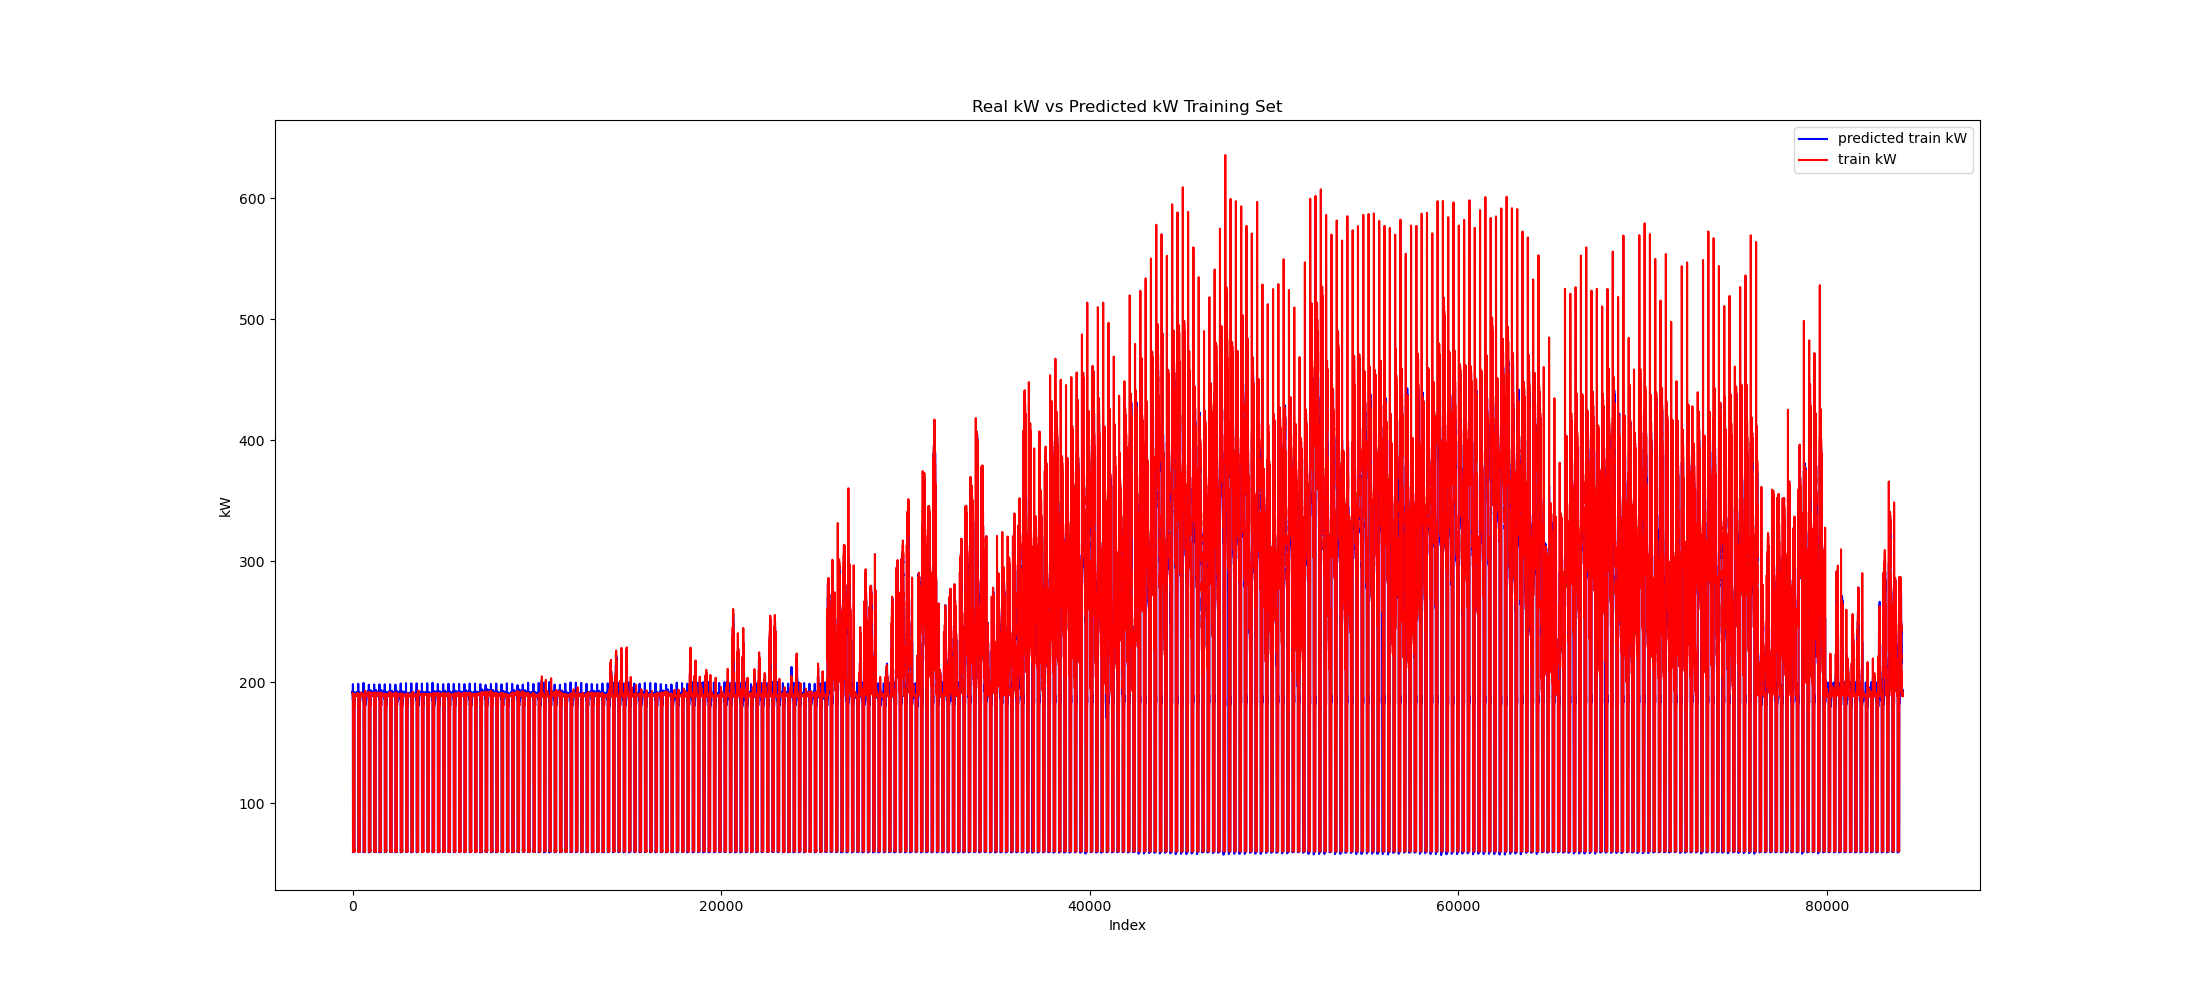

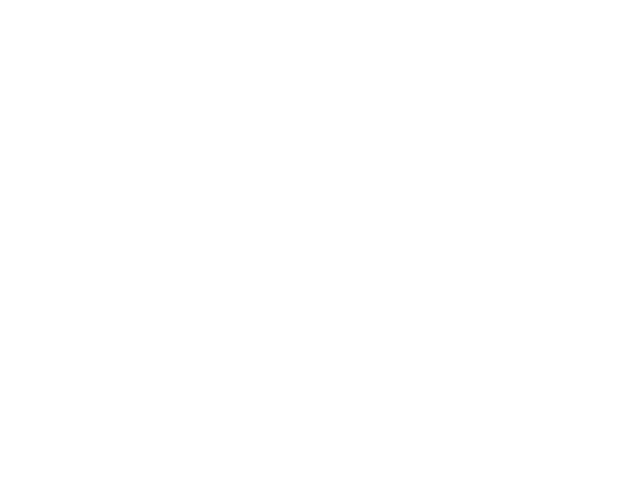

In [12]:
# import matplotlib.pyplot as plt2
plt.clf()
plt.figure(figsize=(22,10))

plt.plot(train_results['Train Predictions'], label="predicted train kW", color="blue")
plt.plot(train_results['Actuals'], label="train kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW Training Set")

# Adding legend
plt.legend()

# # Displaying the
plt.show() 

In [13]:
r2_train = r2_score(train_results['Actuals'], train_results['Train Predictions'])
print("R-squared value of the training set:", r2_train)

trainMaeScore = mean_absolute_error(train_results['Actuals'], train_results['Train Predictions'])
print("MAE of the training set:", trainMaeScore)

trainMseScore = (mean_squared_error(train_results['Actuals'], train_results['Train Predictions']))
print("MSE of the training set:", trainMseScore)

R-squared value of the training set: 0.9817504590024139
MAE of the training set: 5.755905636735266
MSE of the training set: 266.2761352534283


In [14]:
val_predictions = trained_model.predict(X_val1).flatten()
y_val1_flattened = y_val1.flatten()
val_results = pd.DataFrame(data={'Val Predictions':val_predictions, 'Actuals':y_val1_flattened})
val_results

329/329 [==============================] - 20s 56ms/step


,Val Predictions,Actuals
0,192.216019,190.968708
1,191.065002,190.586642
2,191.138062,188.788006
3,192.163544,192.054740
4,191.101944,188.664887
...,...,...
10507,190.160706,189.618847
10508,190.718628,191.072666
10509,190.121597,189.543333
10510,190.787262,191.046402


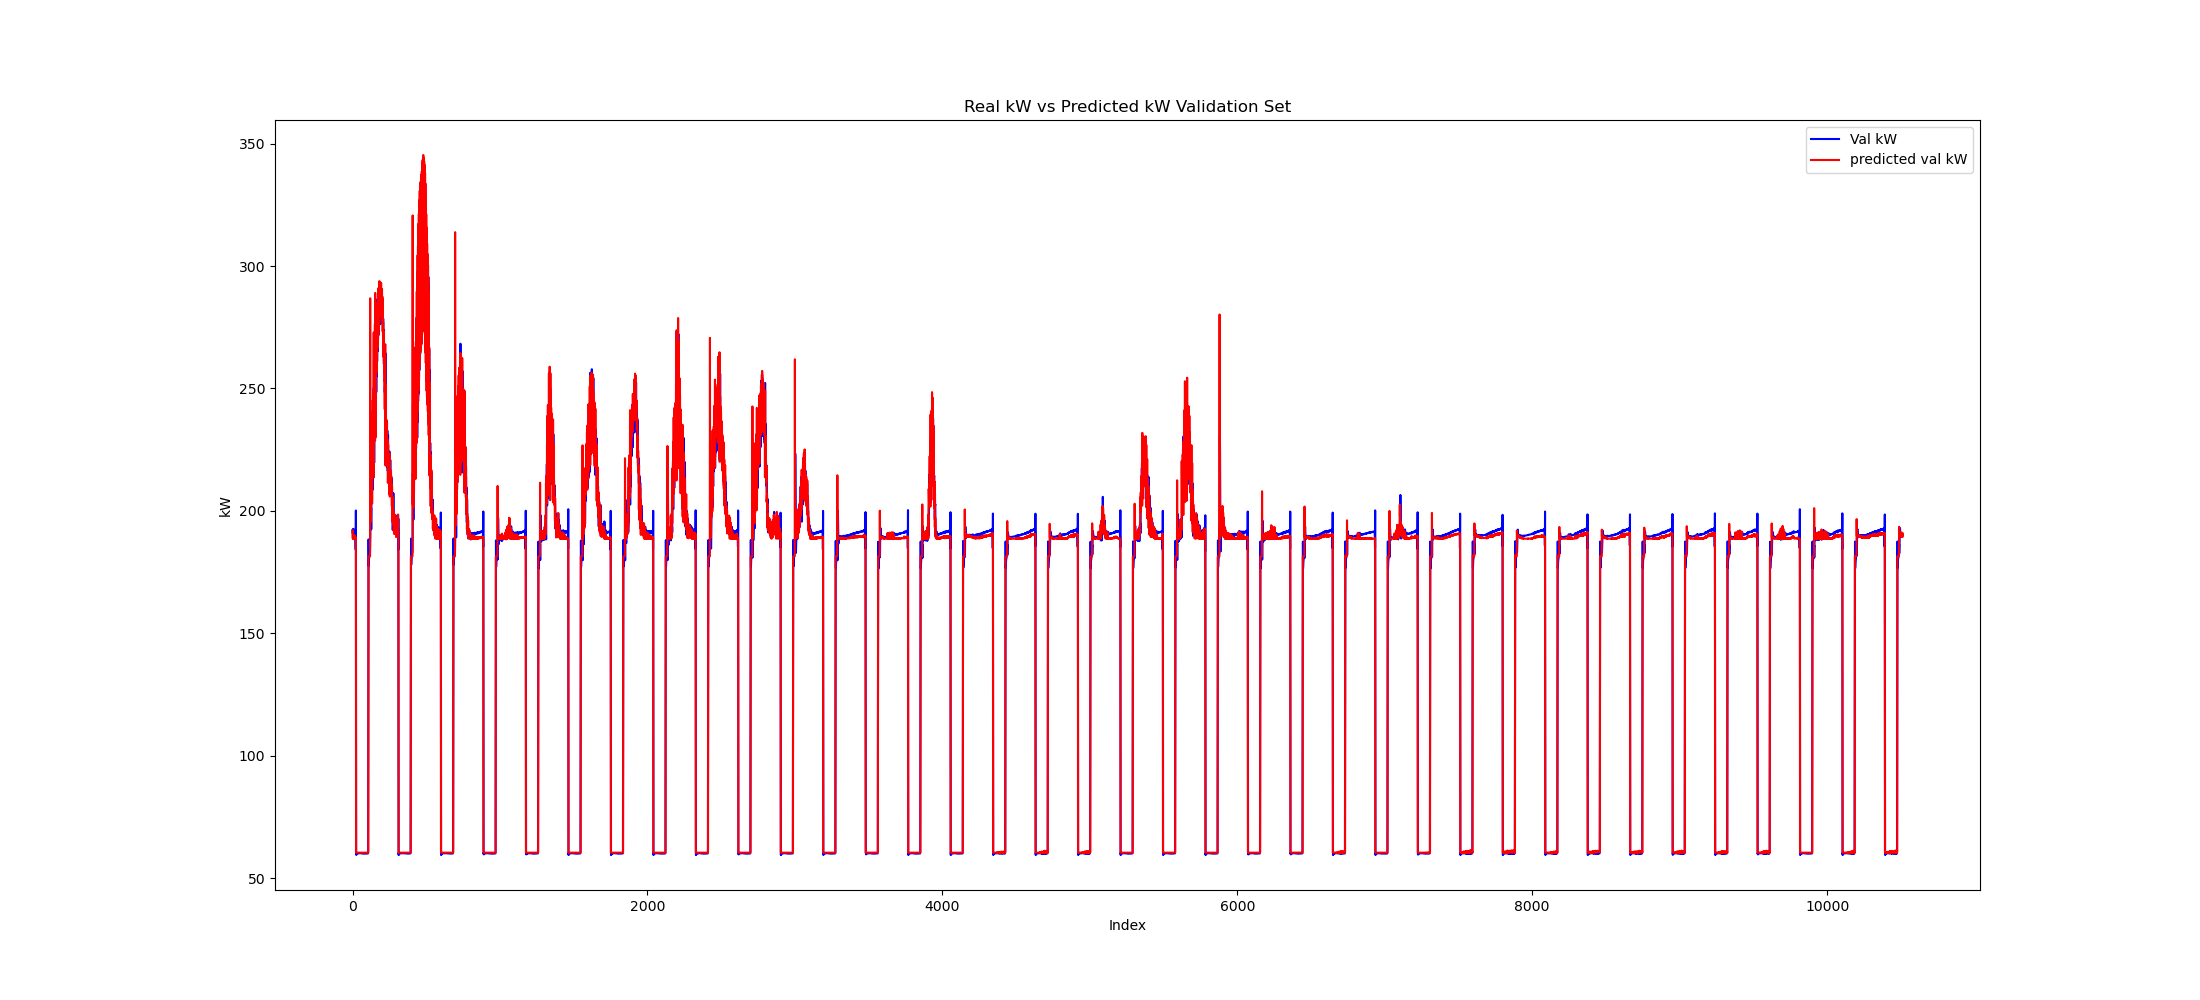

In [15]:
# import matplotlib.pyplot as plt2
# plt.clf()
plt.figure(figsize=(22,10))

plt.plot(val_results['Val Predictions'], label="Val kW", color="blue")
plt.plot(val_results['Actuals'], label="predicted val kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW Validation Set")

# Adding legend
plt.legend()

# # Displaying the
plt.show() 

In [16]:
r2_val = r2_score(val_results['Actuals'], val_results['Val Predictions'])
print("R-squared value of the validation set:", r2_val)

valMaeScore = mean_absolute_error(val_results['Actuals'], val_results['Val Predictions'])
print("MAE of the validation set:", valMaeScore)

valMseScore = (mean_squared_error(val_results['Actuals'], val_results['Val Predictions']))
print("MSE of the validation set:", valMseScore)

R-squared value of the validation set: 0.9867124717273739
MAE of the validation set: 2.7195231570679264
MSE of the validation set: 53.99038740130966


In [17]:
test_predictions = trained_model.predict(X_test1).flatten()
y_test1_flattened = y_test1.flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test1_flattened})
test_results

320/320 [==============================] - 18s 57ms/step


,Test Predictions,Actuals
0,190.811127,191.051684
1,190.174408,189.550000
2,190.801514,190.882790
3,190.250961,189.695463
4,190.724915,190.955050
...,...,...
10219,192.864441,190.877238
10220,193.060486,191.321030
10221,192.886169,190.905346
10222,193.052795,191.417577


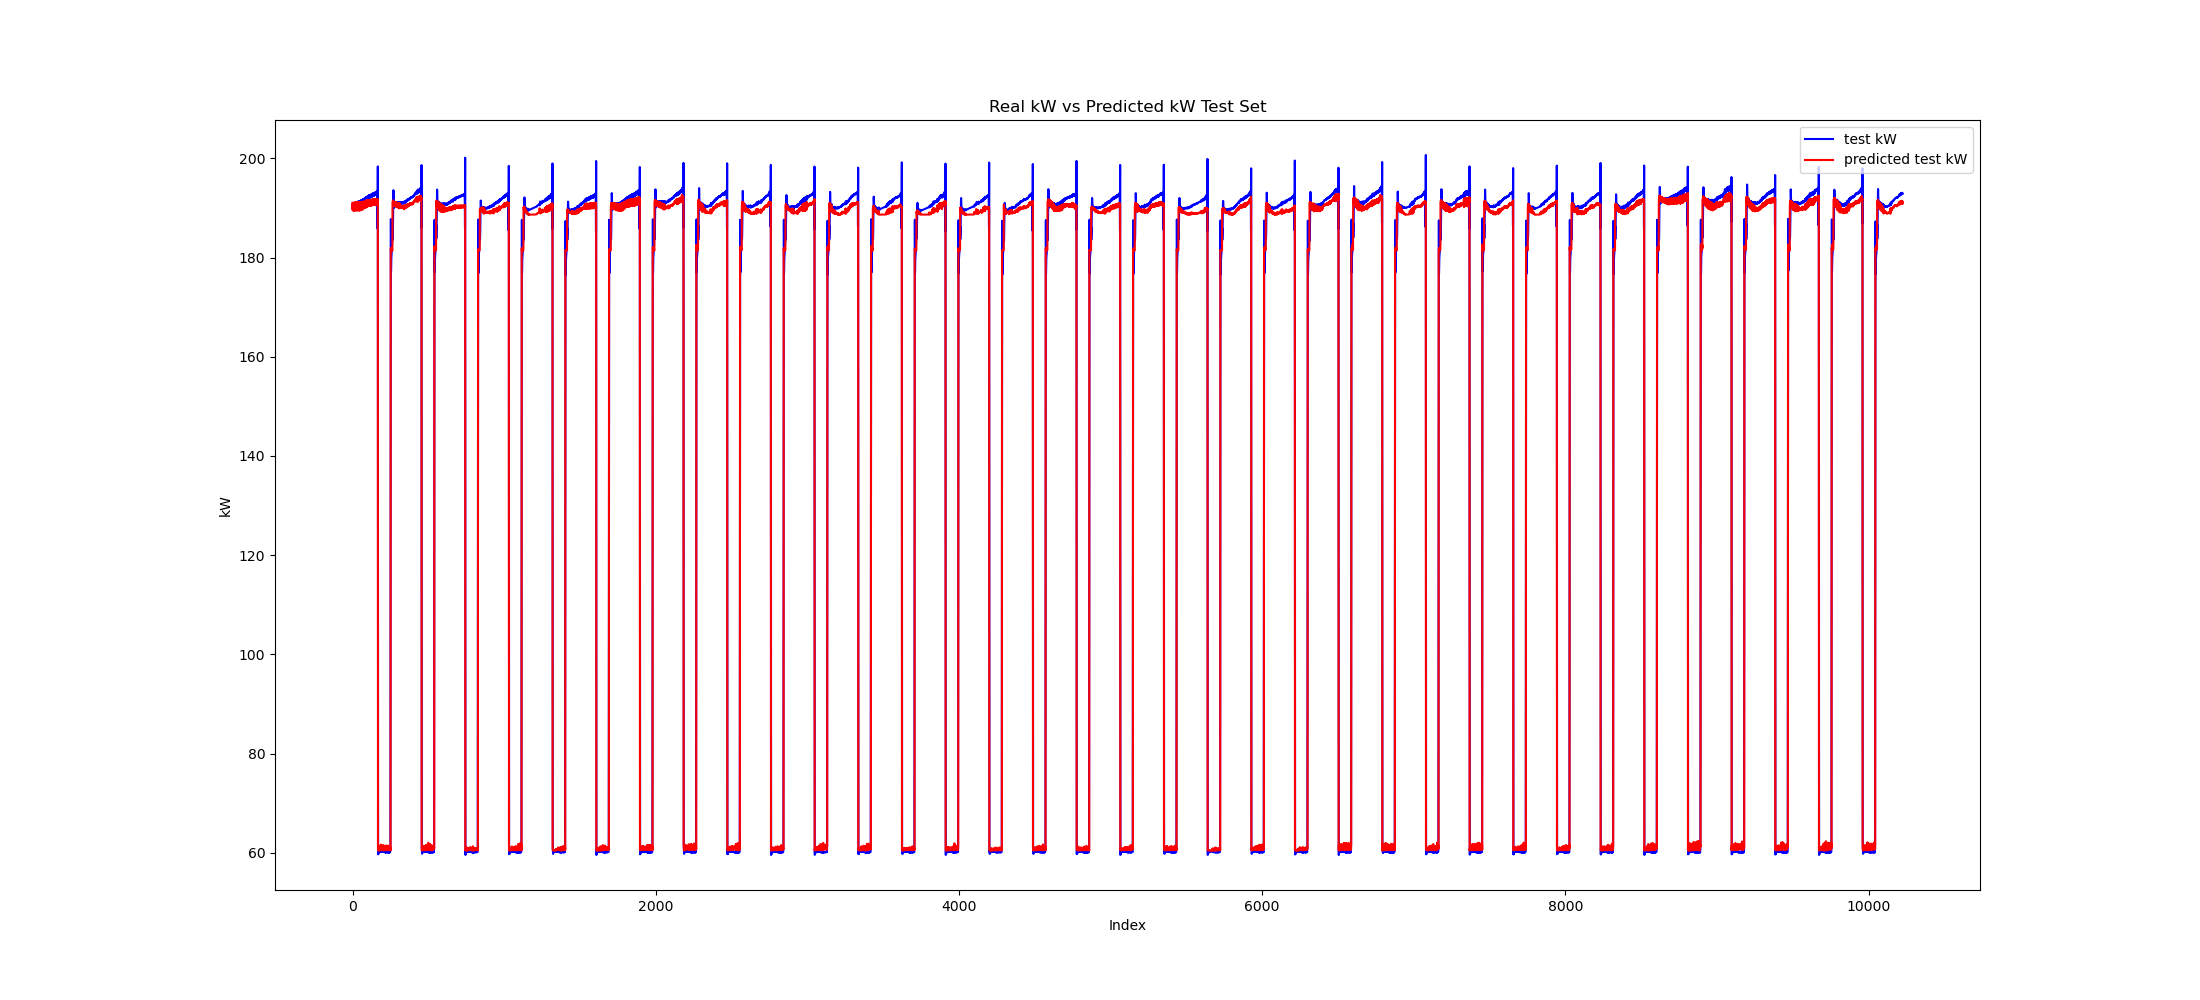

In [18]:
plt.figure(figsize=(22,10))

plt.plot(test_results['Test Predictions'], label="test kW", color="blue")
plt.plot(test_results['Actuals'], label="predicted test kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW Test Set")

# Adding legend
plt.legend()

# # Displaying the
plt.show() 

In [19]:
r2_test = r2_score(test_results['Actuals'], test_results['Test Predictions'])
print("R-squared value of the test set:", r2_test)

testMaeScore = mean_absolute_error(test_results['Actuals'], test_results['Test Predictions'])
print("MAE of the test set:", testMaeScore)

testMseScore = (mean_squared_error(test_results['Actuals'], test_results['Test Predictions']))
print("MSE of the test set:", testMseScore)

R-squared value of the test set: 0.9899089851632916
MAE of the test set: 1.8132026830600931
MSE of the test set: 34.299931448926046
